# WebSky Data Analysis
---
4 layers: CMB + tSZ + mu-distorted tSZ + noise
---
---

### Previous

In [1]:
### IMPORT PACKAGES ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt

import gc
from joblib import Parallel, delayed
from numba import njit, prange
from scipy.interpolate import *
from scipy import stats

from astropy.wcs import WCS
from reproject import reproject_from_healpix

In [2]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic
if 'y_hat_pixel' in locals():
    del y_hat_pixel
if 'residuals_harmonic' in locals():
    del residuals_harmonic
if 'residuals_pixel' in locals():
    del residuals_pixel

gc.collect() # Manually trigger memory cleanup

32

In [3]:
### DEFINITIONS: CONSTANTS, FREQUENCIES, ETC. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Reference noise
#base_sensitivity_uk_arcmin = 30.0
base_sensitivity_uk_arcmin = 2.0

# Theoretical (LCDM) mu-distortion value
mu = 2e-8

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

### Data Reading & Writing

In [4]:
### 1. Load WebSky Components --- https://lambda.gsfc.nasa.gov/simulation/mocks_data.html --- CMB in muK units ###

# These are usually at high resolution (Nside 4096). 
# You might need to downgrade them to Nside 128 or 256 for faster testing.
path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/WebSky_CMB_Mocks/'
path_to_processed_maps = '/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/'

# Set your working resolution and corresponding lmax
nside_work = 2048
#nside_work = 256

print("Reading WebSky maps...")

# A. Load tSZ, downgrade and save it
y_map_raw = hp.read_map(path_to_websky + "tsz.fits")
y_map = hp.ud_grade(y_map_raw, nside_out=nside_work)
#hp.write_map(path_to_websky + "tsz_downgraded.fits", y_map)
hp.write_map(path_to_processed_maps + "y_map.fits", y_map, coord='G', overwrite=True, dtype=np.float32)

# B. Load CMB alms and let it detect the original Lmax ######### CHECK UNITS FOR CMB TOO
# Use return_mmax=True to be extra safe with WebSky's format
alms_cmb, mmax_in = hp.read_alm(path_to_websky + "unlensed_alm.fits", hdu=1, return_mmax=True)

# C. Calculate the Lmax of the file data
lmax_in = hp.Alm.getlmax(len(alms_cmb), mmax_in)

# D. Convert to map. 
# We tell it the ALMs are at 'lmax_in', but we want the result at 'nside_work'
cmb_map = hp.alm2map(alms_cmb, nside=nside_work, lmax=lmax_in, mmax=mmax_in)

# E. Save the clean CMB map (in muK)
# This is your 'Ground Truth' for the CILC (which tries to remove this)
hp.write_map(path_to_processed_maps + "cmb_map.fits", cmb_map, coord='G', overwrite=True, dtype=np.float32)

print("WebSky maps loaded and saved at Nside 2048. Ready for the ILC process.")

Reading WebSky maps...
WebSky maps loaded and saved at Nside 2048. Ready for the ILC process.


In [5]:
### 2. Define the tSZ frequency scaling function g(nu) and Taylor expansion h(nu) ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    return x

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

def get_tsz_h(nu):
    """Calculate the tSZ Taylor expansion frequency scaling h(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    h_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    return h_nu

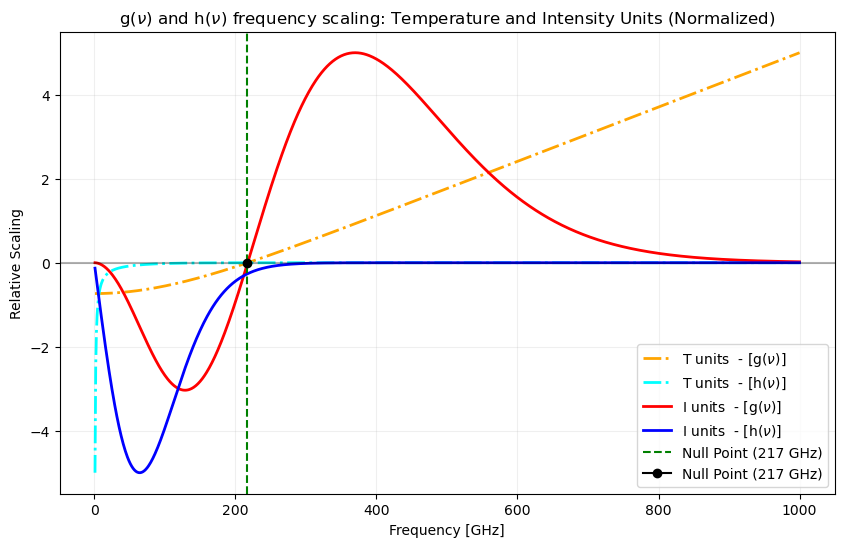

In [6]:
### 3. Compare the tSZ frequency scalings in Intensity and Temperature units ###

def get_tsz_g_intensity_scaling(nu_ghz):
    """The Intensity distortion shape (MJy/sr units)"""
    x = get_physics_constants(nu_ghz)
    # This factor converts dT to dI
    conversion_factor = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
    return conversion_factor * get_tsz_g(nu_ghz)

def get_tsz_h_intensity_scaling(nu_ghz):
    """The Taylor expansion function in Intensity units"""
    x = get_physics_constants(nu_ghz)
    # This factor converts dT to dI
    conversion_factor = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
    return conversion_factor * get_tsz_h(nu_ghz)

# Frequencies for plotting
nu = np.linspace(1, 1000, 1000)
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857] # Planck frequencies in GHz

g = get_tsz_g(nu)
h = get_tsz_h(nu)

g_int = get_tsz_g_intensity_scaling(nu)
h_int = get_tsz_h_intensity_scaling(nu)

# Normalize the Intensity scaling just for visual comparison
g_norm = g / np.max(np.abs(g))
h_norm = h / np.max(np.abs(h))

g_int_norm = g_int / np.max(np.abs(g_int))
h_int_norm = h_int / np.max(np.abs(h_int))

# Plotting
plt.figure(figsize=(10, 6))

# Scalings for Temperature and Intensity
plt.plot(nu, g_norm * 5, label=rf"T units  - [g($\nu$)]", color='orange', lw=2, linestyle='-.')
plt.plot(nu, h_norm * 5, label=rf"T units  - [h($\nu$)]", color='cyan', lw=2, linestyle='-.')
plt.plot(nu, g_int_norm * 5, label=rf"I units  - [g($\nu$)]", color='red', lw=2, linestyle='-')
plt.plot(nu, h_int_norm * 5, label=rf"I units  - [h($\nu$)]", color='blue', lw=2, linestyle='-')

# Null Point and baseline
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(217, color='green', linestyle='--', label='Null Point (217 GHz)')
plt.plot(217,0, marker='o', color='black', label='Null Point (217 GHz)')

# Final touches
plt.title(rf"g($\nu$) and h($\nu$) frequency scaling: Temperature and Intensity Units (Normalized)")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Relative Scaling")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/Users/joanribot/Desktop/Física/Màster UC - UIMP/2n semestre/TFM/Codes/Figures/Scaling_Functions/Intensity_and_Temperature_Scalings.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [7]:
### 4. Create the noise and finally the data_cube_32 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_32 = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map + signal_mu_tsz
    data_cube_32.append(total_map)

data_cube_32 = np.array(data_cube_32, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_32 to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_32_9freq.fits", data_cube_32, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print("Data Cube (muK units) saved successfully as 'data_cube_32_9freq.fits'.")

# Now 'data_cube_32' (muK units) is ready for your ILC functions! 

--- Generating Data Cube (Nside=2048) ---

Summary of noise per pixel:
Frequency: 30  GHz, Noise per pixel: 1.16 uK
Frequency: 44  GHz, Noise per pixel: 1.40 uK
Frequency: 70  GHz, Noise per pixel: 1.63 uK
Frequency: 100 GHz, Noise per pixel: 1.86 uK
Frequency: 143 GHz, Noise per pixel: 2.10 uK
Frequency: 217 GHz, Noise per pixel: 2.33 uK
Frequency: 353 GHz, Noise per pixel: 2.56 uK
Frequency: 545 GHz, Noise per pixel: 2.79 uK
Frequency: 857 GHz, Noise per pixel: 3.03 uK
Saving data_cube_32 to FITS...
Data Cube (muK units) saved successfully as 'data_cube_32_9freq.fits'.


In [ ]:
### 5. Create the noise and finally the data_cube_64 (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube_64 = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")
print(f"\nSummary of noise per pixel:")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # Print the noise level for this frequency for reference
    if nu < 100:
        print(f"Frequency: {nu}  GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    else:
        print(f"Frequency: {nu} GHz, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map + signal_mu_tsz
    data_cube_64.append(total_map)

data_cube_64 = np.array(data_cube_64, dtype=np.float64) # Convert to numpy array for easier handling and ensure it's in float64 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube_64 to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_64_9freq.fits", data_cube_64, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float64)

print("Data Cube (muK units) saved successfully as 'data_cube_64_9freq.fits'.")

# Now 'data_cube_64' (muK units) is ready for your ILC functions! 

### Checking $y$ \& $\mu y$ correlation

In [ ]:
### 6. Create the noise and finally the data_cube_no_muy (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    #signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + signal_tsz + noise_map
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_9freq_no_muy.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print("Data Cube without mu-distorted tSZ signal (muK units) saved successfully as 'data_cube_9freq_no_muy.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

In [ ]:
### 7. Create the noise and finally the data_cube_no_y (muK units) at different frequencies as a supperposition of layers ###

# Data cube structure: [N_freq, N_pix]
data_cube = []

print(f"--- Generating Data Cube (Nside={nside_work}) ---")

for i, nu in enumerate(frequencies):
    # --- FREQUENCY DEPENDENT NOISE LEVEL ---
    # We create a simple multiplier that increases with frequency index as 20% per channel.
    # freq_multiplier = 1.0 for 30GHz, up to 2.8 for 857GHz in this example
    freq_multiplier = 1.0 + (i * 0.2) 
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    
    # Final sigma for this specific pixel at this specific frequency, sigma = S / sqrt(Area_pix) [uK]
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    
    # --- MAP GENERATION ---
    g_nu = get_tsz_g(nu)
    h_nu = get_tsz_h(nu)
    
    # Signal CMB
    signal_cmb = cmb_map # Already in muK units, this is our 'Ground Truth' CMB map

    # Signal tSZ en muK
    #signal_tsz = g_nu * y_map * T_cmb_muK # Convert the tSZ signal to muK units by multiplying by T_cmb in muK

    # Mu-distorted tSZ signal en muK
    signal_mu_tsz = mu * h_nu * y_map * T_cmb_muK # This is the mu-distorted tSZ signal in muK units
    
    # Noise realization (muK units) --- (Unique for each frequency, Mean=0, Sigma=current_sigma_pix, Size=number of pixels, Gaussian distribution)
    # np.random.normal(mean, sigma, size)
    noise_map = np.random.normal(0, current_sigma_pix, len(cmb_map))
    
    # Total map = CMB + tSZ + noise --- (muK units)
    total_map = cmb_map + noise_map + signal_mu_tsz
    data_cube.append(total_map)

data_cube = np.array(data_cube, dtype=np.float32) # Convert to numpy array for easier handling and ensure it's in float32 to save memory --- no!

# Save all 10 frequencies into a single FITS file
# Each frequency will be a different 'column' in the FITS table
print("Saving data_cube to FITS...")
hp.write_map("/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/data_cube_9freq_no_y.fits", data_cube, 
             coord='G', column_names=[f"freq_{f}" for f in frequencies],
             overwrite=True, dtype=np.float32)

print("Data Cube without mu-distorted tSZ signal (muK units) saved successfully as 'data_cube_9freq_no_y.fits'.")

# Now 'data_cube' (muK units) is ready for your ILC functions! 

## I didn't generate new data_cubes_no_y/no_muy for NOISE comparison: 2.0 or 30.0 uK·arcmin